Loading libraries

In [31]:
pip install causalgraphicalmodels

Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import collections.abc
#hyper needs the four following aliases to be done manually.
collections.Iterable = collections.abc.Iterable

from causalgraphicalmodels import StructuralCausalModel
from causalgraphicalmodels.csm import discrete_model, linear_model

Defining a model

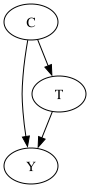

In [33]:
fd0 = StructuralCausalModel({
    "C": lambda n_samples: np.random.binomial(n=1, p=0.5, size=n_samples),
    "T": discrete_model(["C"], {(0,): (0.1,0.9), (1,): (0.9,0.1)}),
    "Y": discrete_model(["T", "C"], {
        (0, 0): (0.1, 0.9),
        (0, 1): (0.5, 0.5),
        (1, 0): (0.9, 0.1),
        (1, 1): (0.3, 0.7),
    }),
})

fd0.cgm.draw()

In [34]:
np.random.seed(0)
n_samples = 10000
set_variable_T = np.array([0]*5000 + [1]*5000)
ab_test_df = fd0.do('T').sample(
                    set_values={'T': set_variable_T},
                    n_samples=n_samples,
                  )
ab_test_df.head()

,C,T,Y
0,1,0,0.0
1,1,0,0.0
2,1,0,1.0
3,1,0,0.0
4,0,0,0.0


Distribution of values of $T$

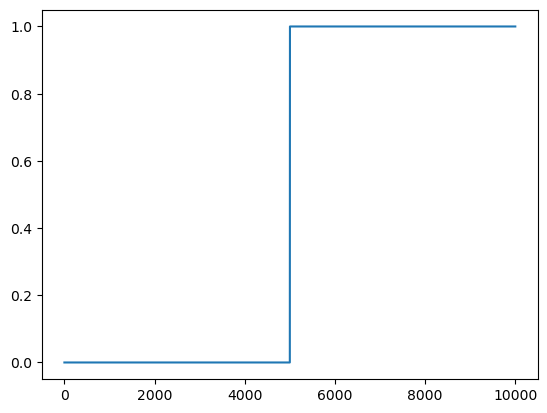

In [35]:
plt.plot(ab_test_df['T'])

Distribution of values of $C$

In [36]:
print('C=0 - {}%'.format((ab_test_df['C'] == 0).sum() / n_samples * 100))
print('C=1 - {}%'.format((ab_test_df['C'] == 1).sum() / n_samples * 100))

C=0 - 50.63999999999999%
C=1 - 49.36%


Distribution of values of $C$ conditioning on $T$

In [37]:
print('T = 0: C = 0 - {}%'.format((ab_test_df[ab_test_df['T'] == 0].C == 0).sum() / (n_samples / 2) * 100 ))
print('T = 0: C = 1 - {}%'.format((ab_test_df[ab_test_df['T'] == 0].C == 1).sum() / (n_samples / 2) * 100 ))
print()
print('T = 1: C = 0 - {}%'.format((ab_test_df[ab_test_df['T'] == 1].C == 0).sum() / (n_samples / 2) * 100 ))
print('T = 1: C = 1 - {}%'.format((ab_test_df[ab_test_df['T'] == 1].C == 1).sum() / (n_samples / 2) * 100 ))

T = 0: C = 0 - 50.82%
T = 0: C = 1 - 49.18%

T = 1: C = 0 - 50.46000000000001%
T = 1: C = 1 - 49.54%


True Causal Effect

In [38]:
true_Y_1 = ab_test_df[ab_test_df['T'] == 1].Y.mean()
true_Y_0 = ab_test_df[ab_test_df['T'] == 0].Y.mean()
print('Y(1)={}'.format(true_Y_1))
print('Y(0)={}'.format(true_Y_0))

Y(1)=0.4018
Y(0)=0.6996


In [39]:
true_ATE = true_Y_1 - true_Y_0
true_ATE

-0.2978

Estimation from the data

In [40]:
np.random.seed(0)
#n_samples = 100000
n_samples = 10000
data_df = fd0.sample(n_samples=n_samples)
data_df.head()

,C,T,Y
0,1,0.0,0.0
1,1,0.0,0.0
2,1,1.0,1.0
3,1,0.0,0.0
4,0,0.0,1.0


In [41]:
Y_1 = data_df[data_df['T'] == 1].Y.mean()
Y_0 = data_df[data_df['T'] == 0].Y.mean()
print('Y(1)={}, error={:.2f}%'.format(Y_1, (true_Y_1 - Y_1)/true_Y_1*100))
print('Y(0)={}, error={:.2f}%'.format(Y_0, (true_Y_0 - Y_0)/true_Y_0*100))

Y(1)=0.15285231564301333, error=61.96%
Y(0)=0.5433688871000201, error=22.33%


In [42]:
ate = Y_1 - Y_0
error_val = (true_ATE - ate) / true_ATE * 100
print('Estimated ATE = {}, error = {:.2f}%'.format(ate, error_val))

Estimated ATE = -0.39051657145700674, error = -31.13%


Back-door adjustment

In [43]:
data_df_C_0 = data_df[data_df['C'] == 0]
data_df_C_1 = data_df[data_df['C'] == 1]
p_C_0 = len(data_df_C_0) / len(data_df)
p_C_1 = len(data_df_C_1) / len(data_df)
print('Probability C=0 is {}'.format(p_C_0))
print('Probability C=1 is {}'.format(p_C_1))

Probability C=0 is 0.5064
Probability C=1 is 0.4936


In [44]:
Y_1 = data_df_C_0[data_df_C_0['T'] == 1].Y.mean() * p_C_0 + data_df_C_1[data_df_C_1['T'] == 1].Y.mean() * p_C_1
Y_0 = data_df_C_0[data_df_C_0['T'] == 0].Y.mean() * p_C_0 + data_df_C_1[data_df_C_1['T'] == 0].Y.mean() * p_C_1

print('Y(1)={}, error={:.2f}%'.format(Y_1, (true_Y_1 - Y_1)/true_Y_1*100))
print('Y(0)={}, error={:.2f}%'.format(Y_0, (true_Y_0 - Y_0)/true_Y_0*100))

Y(1)=0.38719043766819106, error=3.64%
Y(0)=0.7050480761712971, error=-0.78%


In [45]:
ate = Y_1 - Y_0
error_val = (true_ATE-ate) / true_ATE * 100
print('Estimated ATE = {}, error = {:.2f}%'.format(ate, error_val))

Estimated ATE = -0.317857638503106, error = -6.74%
